# Flume water meter - home and irrigation data analyzer

Some Python libraries may need upgrades from default for this to work:

In [ ]:
# Current colab matplotlib version is 3.2.2
# Some of the graphs require matplotlib 3.4 or later (ax.bar_label())
# Upgrade matplotlib to fix this -> should put the runtime at 3.5.3 or later
#!pip install matplotlib --upgrade

In [ ]:
import io
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from datetime import datetime, timedelta, date
import logging

Setup Sprinkler data:
*   Start time for Timer 1 and 2
*   Watering duration in minutes for each station



In [ ]:
T1_START = '02:01:00'
T2_START = '06:30:00'
SPRINKLER_DAYS = [0,2,4] #M, W, F

T1_STATIONS = {
    'T1-01' : 10,
    'T1-02' : 15,
    'T1-03' : 15,
    'T1-04' : 15,
    'T1-05' : 15,
    'T1-06' : 15,
    'T1-07' : 15,
    'T1-08' : 15,
    'T1-09' : 10,
    'T1-10' : 15,
    'T1-11' : 15,
    'T1-12' : 6
}

T2_STATIONS = {
    'T2-01' : 0,
    'T2-02' : 0,
    'T2-03' : 6,
    'T2-04' : 15,
    'T2-05' : 0,
    'T2-06' : 0,
    'T2-07' : 5,
    'T2-08' : 5,
    'T2-09' : 5,
    'T2-10' : 0,
    'T2-11' : 0,
    'T2-12' : 3,
    'T2-13' : 0,
    'T2-14' : 0,
    'T2-15' : 0,
    'T2-16' : 0,
    'T2-17' : 0,
    'T2-18' : 0,
    'T2-19' : 3,
    'T2-20' : 3,
    'T2-21' : 3,
    'T2-22' : 3,
    'T2-23' : 3,
    'T2-24' : 3,
    'T2-25' : 3,
}

SPRINKLER_ON_THRESHOLD = 500 #If more than 500 gallons are used in a given morning - assume it's sprinklers

The water bill shows "units" which are 748 gallons - setup constants for this:

In [ ]:
# Gallons per unit (GPU) == 748 gallons
GPU = 748

# Water bills reflect how much water was used since the last meter reading.
# Meters measure cubic feet of water used (one cubic foot equals 7-1/2 gallons).
# EBMUD bills in units of 100 cubic feet (748 gallons).
# Recent bill worked out to ~ $10.47 / unit
GPU_COST = 10.47

In [ ]:
#Setup logging
logger = logging.getLogger('my_logger')
logging.basicConfig(level=logging.DEBUG, force=True)

logger.debug("DEBBUG - bar is a test log ..")
logger.info("INFO - foo is a test log ..")
logger.warning('WARNING - This is a test log ..')

DEBUG:my_logger:DEBBUG - bar is a test log ..
INFO:my_logger:INFO - foo is a test log ..


Define helper functions

In [ ]:
def addMinutes (sometime, delta) :
  # add delta to sometime
  #
  # Args:
  #  sometime - a datetime.time object
  #  delta - minutes to add (integer)
  #
  # Returns:
  #  sometime+delta as datetime.time object

  later = (datetime.combine(date.today(), sometime) + timedelta(minutes=delta)).time()
  return later


def addSprlinkersToDataframe (df, start, stations):
  # Populate flume dataframe['Sprinkler'] column with the sprinkler running at
  # dataframe.['datetime'] time.  Assumes the dataframe already had
  # df['Sprinkler'] column added and populated with 'house' for all rows
  #
  # TODO: ASSUMES sprinkler day of week is M/W/F, turn this into a paramater...  <-- DONE
  #
  # Args:
  #  df - Dataframe with Flume data and the 'Sprinkler' column added
  #  start - string in 'hh:mm:ss' format representing the starting time of the
  #          first sprinkler on this timer
  #  stations - dict with station name as key, duration in minutes as value
  #
  # Returns:
  #  df with station name populated in the 'Sprinkler' column for every minute
  #  of a day that sprinkler was active

  t1 = datetime.strptime(start, '%H:%M:%S').time()
  for sprinkler, duration in stations.items():
    t2 = addMinutes(t1, duration)
    #mask = (df['Time'] > t1) & (df['Time'] <= addMinutes(t1, duration)) & df.index.weekday.isin([0,2,4])
    mask = (df['Time'] > t1) & (df['Time'] <= addMinutes(t1, duration)) & (df['isSprinklerDay'] == True) # <-- DONE
    df.loc[mask, 'Sprinkler'] = sprinkler
    t1=t2
  return df


def addSprinklerDayBoolToDataFrame (sprinkler_df):
  # Determine if sprinklers ran on this day.  If water between 2AM-8AM exceeds
  # threshold, assume it is a sprinkler day and set
  # sprinkler_df.isSprinklerDay = True
  #
  # Args:
  #  sprinkler_df - Dataframe with Flume data and the 'Sprinkler' column added

  #Setup start and end time - assume end time is 2 hours after T2_START.
  #TODO: fix assumption, remove magic #
  sprinkler_start = datetime.strptime(T1_START, '%H:%M:%S').time()
  sprinkler_end = addMinutes(datetime.strptime(T2_START, '%H:%M:%S').time(), 120)

  logger.debug("addSprinklerDayBoolToDataFrame: start: "+sprinkler_start.strftime("%H:%M:%S"))
  logger.debug("addSprinklerDayBoolToDataFrame: end: "+sprinkler_end.strftime("%H:%M:%S"))

  #Get a dataframe with gallons per second for seconds between sprinkler_start and sprinkler_end
  mask = (sprinkler_df['Time'] >= sprinkler_start) & (sprinkler_df['Time'] <= sprinkler_end)
  masked_df = sprinkler_df.loc[mask]

  #Create a new dataframe that aggregates by day - each row is total volume during sprinkler time for that day
  sprinkler_days_df = masked_df.groupby('Date')['gallons'].sum().reset_index()

  #if more water was used during sprinkler time than threshold, assume sprinklers were running
  #logger.debug('setting sprinkler days:')
  sprinkler_days_df.loc[sprinkler_days_df['gallons'] > SPRINKLER_ON_THRESHOLD, 'isSprinklerDay'] = True

  #set sprinkler_df isSprinklerDay column accordingly
  days_is_true_df = sprinkler_days_df.loc[sprinkler_days_df['isSprinklerDay'] == True]
  days = days_is_true_df['Date'].tolist()

  for day in days:
    sprinkler_df.loc[sprinkler_df['Date'] == day, 'isSprinklerDay'] = True
    #logger.debug('setting sprinkler day true: '+str(day))


def getDailySprinklerDataframe (df) :
  # Return a dataframe with one day per row and a column per sprinkler + a
  # column for "house" - all water used when no sprinkler is running
  #
  # Args:
  #  df - flume dataframe with sprlinklers added
  #
  # Returns:
  #  new dataframe with daily aggregation described above

  daily_df = df.pivot_table(index=['Date'], columns=['Sprinkler'],
                            values=['gallons'], aggfunc='sum')
  #table.to_csv('sprinkler_data.csv')

  return daily_df


def getSprinklerStartTime (flowDF, estStartTime, flowThreshold = 100, startWindowMin = 20):
  # flowDF is expected to be a single day's dataframe.  Within it:
  # search for an increase >= flowThresh within +/- startWindow of estStartTime
  # return that time as datetime.time()

  #searchStart = estStartTime - StartWindow
  #for frame, frame+1 in df, if frame + flowThresh < frame+1, return frame+1 datetime
  print ('TODO getSprinklerStartTime ')
  return estStartTime

Load flume data into a Pandas Dataframe

In [ ]:
# load data from github:
#giturl = 'https://raw.githubusercontent.com/DeDuva/sprinkler/main/export_2022-10-10T01_00_00.000_2022-10-12T12_00_00.000.csv'
#giturl = 'https://raw.githubusercontent.com/DeDuva/sprinkler/main/export_2022-08-29T08_00_00.000_2022-10-07T12_00_00.000.csv'
giturl = 'https://raw.githubusercontent.com/DeDuva/sprinkler/main/export_2023-05-27T01_00_00.000_2023-06-19T08_00_00.000.csv'
df = pd.read_csv(giturl, parse_dates=['datetime'])
df = df.set_index(['datetime'])

Add columns to the data to simplify analysis

In [ ]:
df['Date'] = df.index.date
df['Time'] = df.index.time
df['WeekdayName'] = df.index.day_name()
df['Sprinkler'] = "house" #default all entries to 'house', will replace with the station # at appropriate day/time
df['isSprinklerDay'] = False #default all days to false, will update to True for any day that sprinklers ran

Main program:

In [ ]:
addSprinklerDayBoolToDataFrame (df)

# Group by Date and sum gallons to get _sprinkler_days_df
_sprinkler_days_df = df.groupby('Date')['gallons'].sum().reset_index()

# Determine total number of unique days in the timeseries
total_days = _sprinkler_days_df.shape[0]
print("Total days in data: " + str(total_days))

# Count unique days where isSprinklerDay is True
sprinkler_days = df[df['isSprinklerDay'] == True]['Date'].unique().shape[0]
print("Total sprinkler days in data: " + str(sprinkler_days))


DEBUG:my_logger:addSprinklerDayBoolToDataFrame: start: 02:01:00
DEBUG:my_logger:addSprinklerDayBoolToDataFrame: end: 08:30:00


Total days in data: 24
Total sprinkler days in data: 9


In [ ]:
addSprlinkersToDataframe (df, T1_START, T1_STATIONS)
addSprlinkersToDataframe (df, T2_START, T2_STATIONS)
dailyDF = getDailySprinklerDataframe (df)

# Summarize the data:

print ("")
print ("---")

print ("Dates: ", df.iloc[0]['Date'], ' : ', df.iloc[-1]['Date'])

total_g = df['gallons'].sum()
sprinkler_df = df[df['Sprinkler'].str.contains('T')]
sprinkler_g = sprinkler_df['gallons'].sum()

print ("            Gallons      Units")
print ("Total:      {:,.1f}      {:,.1f}".format(total_g, total_g/GPU))
print ("Sprinklers: {:,.1f}      {:,.1f}".format(sprinkler_g, sprinkler_g/GPU))

#df2 = df['9/11/2022':'9/17/2022']
#df2 = df

#total_g = df2['gallons'].sum()
#logger.debug ('total_g {0:4.1f}'.format(total_g))

#sdf2 = df2[df2['Sprinkler'].str.contains('T')]
#sprinkler_g = sdf2['gallons'].sum()
#logger.debug ('sprinkler_g {0:4.1f}'.format(sprinkler_g))

sprinkler_units = sprinkler_g / GPU
logger.debug ('sprinkler_units {0:4.1f}'.format(sprinkler_units))

total_units = total_g / GPU
total_cost = total_units * GPU_COST

print ("---------------------")
print ("                      Sprinklers  Total  %Total   Total Cost  ")
print ("Per week utilization: {0:4.1f}         {1:4.1f}    {2:4.0%}     ${3:4.2f}".format(sprinkler_units, total_units, sprinkler_units/total_units, total_cost))
print ("Est. per bill:        {0:4.1f}         {1:4.1f}    {2:4.0%}     ${3:4.2f}".format(sprinkler_units*8, total_units*8, sprinkler_units/total_units, total_cost*8))
print ("---------------------")

DEBUG:my_logger:sprinkler_units 19.2



---
Dates:  2023-05-27  :  2023-06-19
            Gallons      Units
Total:      23,143.0      30.9
Sprinklers: 14,381.9      19.2
---------------------
                      Sprinklers  Total  %Total   Total Cost  
Per week utilization: 19.2         30.9     62%     $323.94
Est. per bill:        153.8         247.5     62%     $2591.52
---------------------


In [ ]:
#gemini version:
# prompt: create a timeseries chart showing gallons per day on the Y-axis and day on the x-axis from df which has time series data with gallons per minute every minute per day

# Group data by day and sum
# df_daily = df.groupby(pd.Grouper(key='Date', freq='D')).sum() -- gemini fail, using chatgpt:

#daily_gallons = df.groupby(df['Date'])['gallons'].sum().reset_index()
#daily_gallons = df.groupby(pd.Grouper(key='Date', freq='D')).agg({'gallons': 'sum', 'isSprinklerDay': 'any'})
daily_gallons = df.groupby(df['Date']).agg({'gallons': 'sum', 'isSprinklerDay': 'any'}).reset_index()
daily_gallons.columns = ['Date', 'Total Gallons', 'isSprinklerDay']  # Rename columns for clarity

# Create the interactive bar chart
fig = go.Figure(data=[go.Bar(x=daily_gallons.index, y=daily_gallons['Total Gallons'],
                            marker=dict(color=['blue' if isSprinklerDay else 'red' for isSprinklerDay in daily_gallons['isSprinklerDay']]))])

fig.update_layout(
    title='Total Gallons Per Day Over Time',
    xaxis_title='Date',
    yaxis_title='Total Gallons'
)

fig.show()


In [ ]:
# chatGPT version
# Aggregate gallons per day
daily_gallons = df.groupby(df['Date'])['gallons'].sum().reset_index()
daily_gallons.columns = ['Date', 'Total Gallons']  # Rename columns for clarity

# Create the bar chart
fig = px.bar(daily_gallons, x='Date', y='Total Gallons',
             title='Total Gallons per Day',
             labels={'Date': 'Date', 'Total Gallons': 'Total Gallons'},
             hover_data={'Date': True, 'Total Gallons': True})

# Show the figure
fig.show()


                         mean         min          max         std
        Sprinkler                                                 
gallons T1-01       14.128111   12.683670    18.187307    1.770721
        T1-02       79.890604   77.873306    85.290565    2.321557
        T1-03      119.206818  117.458376   124.021622    2.087379
        T1-04       82.262861   80.229749    85.733386    1.858237
        T1-05      109.515707  108.016791   115.244269    2.265568
        T1-06       87.379908   84.136066    91.316099    2.690447
        T1-07       57.847938   56.080167    61.836846    1.817386
        T1-08       31.297984   29.842999    35.568047    1.814738
        T1-09      114.991229  111.685883   117.569082    2.141261
        T1-10      146.494808   89.797854   193.465507   52.966399
        T1-11       47.909058   30.760272    63.703021   14.371062
        T1-12       50.457038   44.044914    69.254104    7.717559
        T2-03       49.799835    0.031630    58.104494   18.70

<Axes: title={'center': 'Daily Sprinkler Flow (g)'}, xlabel='None,Sprinkler'>

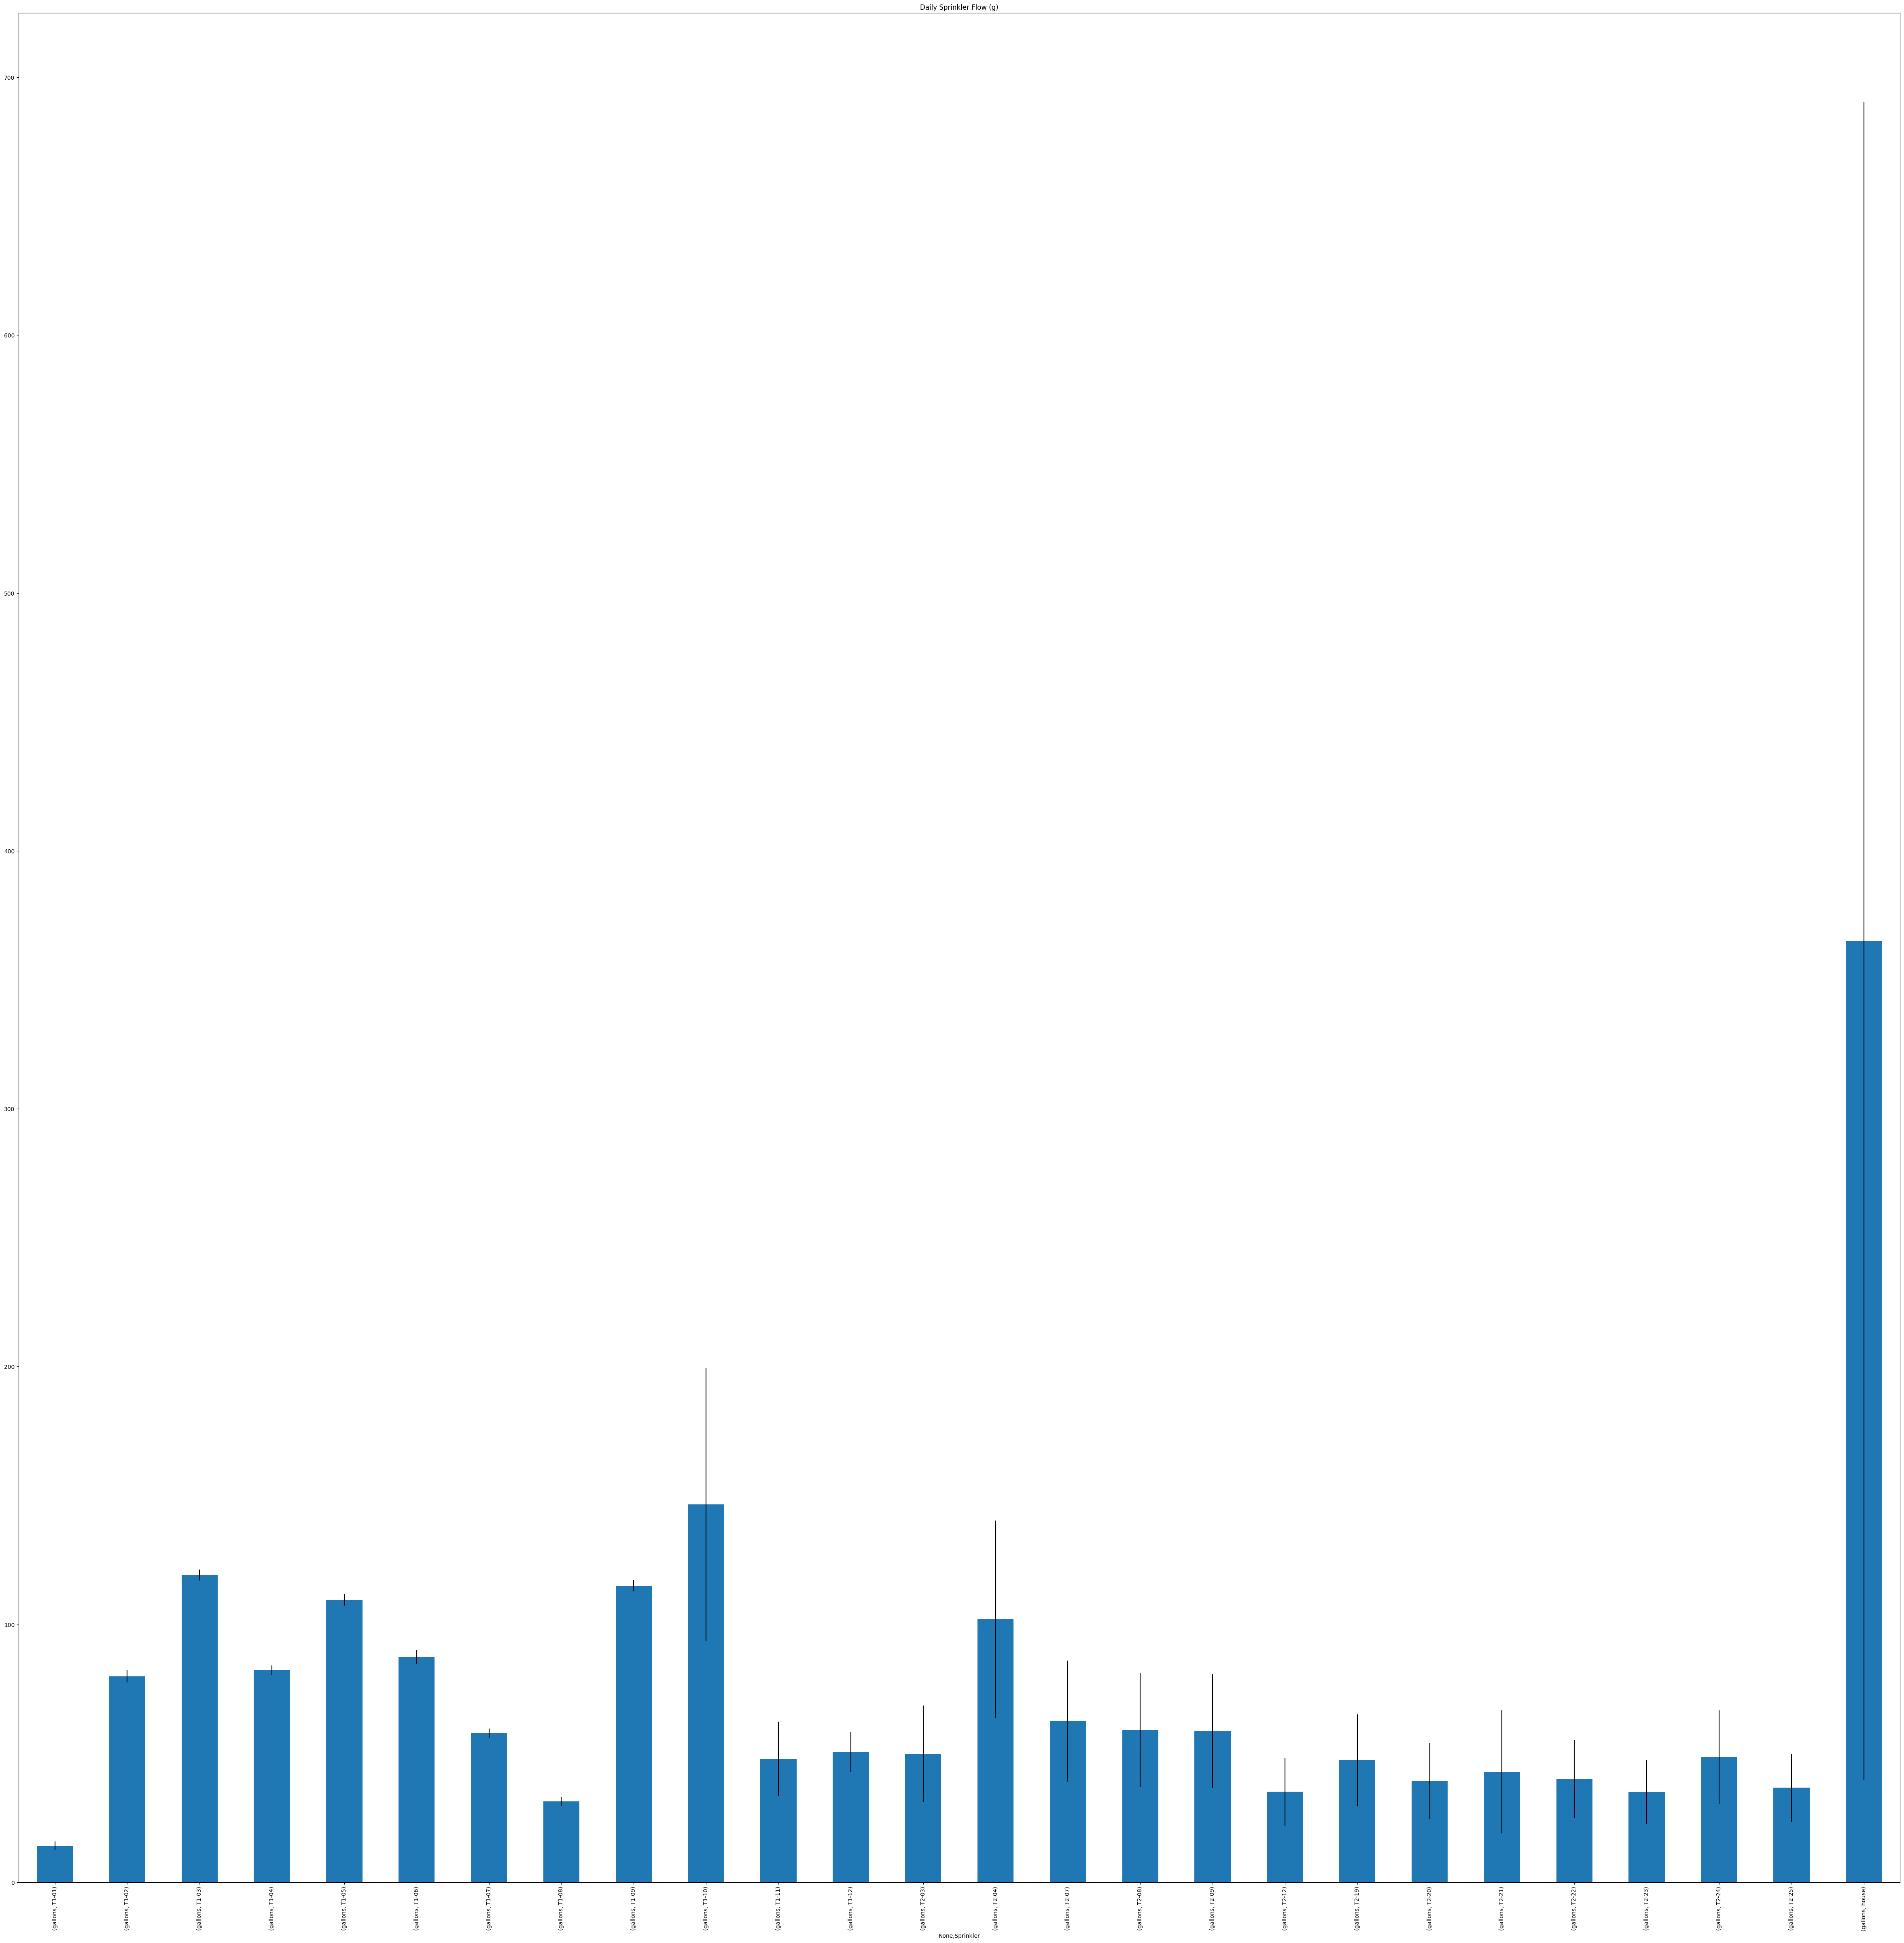

In [ ]:
result = df.groupby('Sprinkler').agg({'gallons': ['mean', 'min', 'max', 'std']})

flow = result['gallons']
#ax = flow.plot.barh(y = "mean", legend = False, title = "Sprinkler Flow Rate (gpm)", figsize=(60,60))
#ax.bar_label(ax.containers[0], fmt='%.2f')
fig = px.bar(flow, x='mean', title="Sprinkler Flow Rate (gpm)")
fig.show()

daily = dailyDF.describe().transpose()
daily_summary_agg = daily[['mean', 'min', 'max', 'std']]
print(daily_summary_agg)
daily_summary_agg.plot(kind = "bar", y = "mean", legend = False, yerr = 'std', title = "Daily Sprinkler Flow (g)", figsize=(60,60))
#fig = px.bar(daily_summary_agg, y='mean', title = 'Daily Sprinkler Flow (g)')

Details for a specific day:

In [ ]:
day_query = "2023-06-19" #@param {type:"date"}

date_time_obj = datetime.strptime(day_query, '%Y-%m-%d')

if not (date_time_obj.weekday() in (SPRINKLER_DAYS)):
  print ('Not a sprinkler day!')
  assert(False)

df_day = df.loc[day_query]

logger.debug("df_day.head()")
logger.debug(df_day.head())

total_g = df_day['gallons'].sum()
sdf2 = df_day[df_day['Sprinkler'].str.contains('T')]
sprinkler_g = sdf2['gallons'].sum()
house_g = total_g - sprinkler_g

day_sprinkler_units = sprinkler_g / GPU
day_total_units = total_g / GPU
day_house_units = house_g / GPU
day_total_cost = day_total_units * GPU_COST

est_bill_sprinkler_units = day_sprinkler_units * 3 * 8
est_bill_house_units = day_house_units * 7 * 8
est_total_units = est_bill_house_units + est_bill_sprinkler_units
est_total_cost = est_total_units * GPU_COST

print ("---------------------")
print ("                      Sprinklers  Total  %Total   Total Cost  ")
print ("{0:} utilization: {1:4.1f}         {2:4.1f}    {3:4.0%}     ${4:4.2f}".format(day_query, sprinkler_units, total_units, sprinkler_units/total_units, total_cost))
print ("Est. per bill:          {0:4.1f}         {1:4.1f}    {2:4.0%}     ${3:4.2f}".format(est_bill_sprinkler_units, est_total_units, est_bill_sprinkler_units/est_total_units, est_total_cost))
print ("---------------------")

result = df_day.groupby('Sprinkler').agg({'gallons': ['mean', 'min', 'max', 'std']})
flow = result['gallons']
fig = px.bar(flow, x='mean', title="Sprinkler Flow Rate (gpm)")
fig.show()

result2 = df_day.groupby('Sprinkler')['gallons'].sum()
fig2 = px.bar (result2, y='gallons')
fig2.show()

DEBUG:my_logger:df_day.head()
DEBUG:my_logger:                      gallons        Date      Time WeekdayName Sprinkler  \
datetime                                                                    
2023-06-19 00:00:00  0.142335  2023-06-19  00:00:00      Monday     house   
2023-06-19 00:01:00  0.142335  2023-06-19  00:01:00      Monday     house   
2023-06-19 00:02:00  0.158150  2023-06-19  00:02:00      Monday     house   
2023-06-19 00:03:00  0.142335  2023-06-19  00:03:00      Monday     house   
2023-06-19 00:04:00  0.142335  2023-06-19  00:04:00      Monday     house   

                     isSprinklerDay  
datetime                             
2023-06-19 00:00:00            True  
2023-06-19 00:01:00            True  
2023-06-19 00:02:00            True  
2023-06-19 00:03:00            True  
2023-06-19 00:04:00            True  


---------------------
                      Sprinklers  Total  %Total   Total Cost  
2023-06-19 utilization: 19.2         30.9     62%     $323.94
Est. per bill:          50.3         68.0     74%     $711.93
---------------------


In [ ]:
import plotly.graph_objects as go
import pandas as pd

# Assuming df has the required columns: Date, Sprinkler, Gallons, isSprinklerDay

# Sample df if you want to test
# data = {
#     'Date': ['2024-10-01', '2024-10-01', '2024-10-01', '2024-10-02', '2024-10-02', '2024-10-02', '2024-10-03', '2024-10-03', '2024-10-03'],
#     'Sprinkler': ['Sprinkler1', 'Sprinkler2', 'Sprinkler3', 'Sprinkler1', 'Sprinkler2', 'Sprinkler3', 'Sprinkler1', 'Sprinkler2', 'Sprinkler3'],
#     'Gallons': [100, 80, 120, 50, 40, 60, 0, 0, 0],
#     'isSprinklerDay': [True, True, True, True, True, True, False, False, False]
# }
# df = pd.DataFrame(data)

# Pivot the data for sprinkler days and non-sprinkler days
df_pivot = df.pivot_table(index='Date', columns='Sprinkler', values='gallons', aggfunc='sum').fillna(0)

# Extract sprinkler days (where isSprinklerDay == True) and non-sprinkler days
sprinkler_days = df[df['isSprinklerDay'] == True].drop_duplicates(subset='Date')
non_sprinkler_days = df[df['isSprinklerDay'] == False].drop_duplicates(subset='Date')

# Create the figure
fig = go.Figure()

# Add stacked bars for sprinkler days
for sprinkler in df_pivot.columns:
    fig.add_trace(go.Bar(
        x=sprinkler_days['Date'],
        y=df_pivot.loc[sprinkler_days['Date'], sprinkler],
        name=sprinkler
    ))

# Add bars for non-sprinkler days (single color)
fig.add_trace(go.Bar(
    x=non_sprinkler_days['Date'],
    y=[0] * len(non_sprinkler_days),  # No water used on non-sprinkler days
    name='Non-Sprinkler Day',
    marker_color='gray'  # Different color for non-sprinkler days
))

# Update the layout
fig.update_layout(
    barmode='stack',  # Stack bars on top of each other
    title='Water Consumption by Sprinkler (Including Non-Sprinkler Days)',
    xaxis_title='Date',
    yaxis_title='Gallons',
    legend_title='Sprinklers',
    showlegend=True
)

# Show the figure
fig.show()

In [ ]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource
from bokeh.layouts import column

output_notebook()

# Prepare data (as before)
df_pivot = df.pivot_table(index='Date', columns='Sprinkler', values='gallons', aggfunc='sum').fillna(0)

# Separate days
sprinkler_days = df[df['isSprinklerDay'] == True].drop_duplicates(subset='Date')
non_sprinkler_days = df[df['isSprinklerDay'] == False].drop_duplicates(subset='Date')

# Bokeh data source for sprinkler days
source = ColumnDataSource(df_pivot.loc[sprinkler_days['Date']])

# Create a figure
p = figure(x_range=sprinkler_days['Date'].astype(str), title="Water Consumption by Sprinkler")

# Add stacked bars
p.vbar_stack(['Sprinkler1', 'Sprinkler2', 'Sprinkler3'], x='Date', width=0.9, source=source,
             legend_label=['Sprinkler 1', 'Sprinkler 2', 'Sprinkler 3'], color=["#718dbf", "#e84d60", "#ddb7b1"])

# Non-sprinkler days as gray bars
p.vbar(x=non_sprinkler_days['Date'].astype(str), top=0, width=0.9, color='gray', legend_label="Non-Sprinkler Day")

# Customize
p.xaxis.major_label_orientation = 1
p.yaxis.axis_label = 'gallons'
p.legend.title = 'Sprinkler'

# Show the plot
show(p)
